This project aims to predict laptop prices based on various features and specifications using machine learning algorithms. The dataset contains information about different laptop models, their configurations, and corresponding prices.

### Objective
The primary goal of this project is to leverage machine learning techniques to predict laptop prices based on their specifications.

* Data Exploration: Analyzed correlations between laptop features and prices. 

* Feature Engineering: Created new features like 'TouchScreen' and 'IPS Display'.

* Preprocessing: Handled missing values, converted data types, and cleaned the dataset. 

* Model Building: Employed regression models including Linear Regression, Decision Tree Regressor, Random Forest Regressor, AdaBoost Regressor, and XGBoost Regressor.

* Model Evaluation: Assessed models using metrics like Mean Squared Error, Mean Absolute Error, and R-squared.

* Hyperparameter Tuning: Optimized the Random Forest Regressor using GridSearchCV.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("laptop_data.csv")

In [4]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [5]:
df.tail()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.64
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.72
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92
1302,1302,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32


In [6]:
df['ScreenResolution'].unique()

array(['IPS Panel Retina Display 2560x1600', '1440x900',
       'Full HD 1920x1080', 'IPS Panel Retina Display 2880x1800',
       '1366x768', 'IPS Panel Full HD 1920x1080',
       'IPS Panel Retina Display 2304x1440',
       'IPS Panel Full HD / Touchscreen 1920x1080',
       'Full HD / Touchscreen 1920x1080',
       'Touchscreen / Quad HD+ 3200x1800',
       'IPS Panel Touchscreen 1920x1200', 'Touchscreen 2256x1504',
       'Quad HD+ / Touchscreen 3200x1800', 'IPS Panel 1366x768',
       'IPS Panel 4K Ultra HD / Touchscreen 3840x2160',
       'IPS Panel Full HD 2160x1440',
       '4K Ultra HD / Touchscreen 3840x2160', 'Touchscreen 2560x1440',
       '1600x900', 'IPS Panel 4K Ultra HD 3840x2160',
       '4K Ultra HD 3840x2160', 'Touchscreen 1366x768',
       'IPS Panel Full HD 1366x768', 'IPS Panel 2560x1440',
       'IPS Panel Full HD 2560x1440',
       'IPS Panel Retina Display 2736x1824', 'Touchscreen 2400x1600',
       '2560x1440', 'IPS Panel Quad HD+ 2560x1440',
       'IPS Panel 

In [7]:
'''
patterns = [
    'Full HD 1920x1080',
    '1366x768',
    'IPS Panel Full HD 1920x1080',
    '1600x900',
    'IPS Panel 4K Ultra HD 3840x2160',
    '4K Ultra HD 3840x2160',
    'IPS Panel 1366x768',
    'IPS Panel Retina Display 2560x1600',
    'IPS Panel Retina Display 2304x1440',
    '1440x900',
    'IPS Panel 2560x1440',
    'IPS Panel Quad HD+ 2560x1440',
    'Quad HD+ 3200x1800',
    '1920x1080',
    '2560x1440',
    'IPS Panel Full HD 2160x1440',
    'IPS Panel Quad HD+ 3200x1800',
    'IPS Panel Retina Display 2736x1824',
    'IPS Panel Full HD 1920x1200',
    'IPS Panel Touchscreen 2400x1600'
]

df['ScreenResolution'] = df['ScreenResolution'].replace(
    patterns,
    'IPS Panel'
)

'''

"\npatterns = [\n    'Full HD 1920x1080',\n    '1366x768',\n    'IPS Panel Full HD 1920x1080',\n    '1600x900',\n    'IPS Panel 4K Ultra HD 3840x2160',\n    '4K Ultra HD 3840x2160',\n    'IPS Panel 1366x768',\n    'IPS Panel Retina Display 2560x1600',\n    'IPS Panel Retina Display 2304x1440',\n    '1440x900',\n    'IPS Panel 2560x1440',\n    'IPS Panel Quad HD+ 2560x1440',\n    'Quad HD+ 3200x1800',\n    '1920x1080',\n    '2560x1440',\n    'IPS Panel Full HD 2160x1440',\n    'IPS Panel Quad HD+ 3200x1800',\n    'IPS Panel Retina Display 2736x1824',\n    'IPS Panel Full HD 1920x1200',\n    'IPS Panel Touchscreen 2400x1600'\n]\n\ndf['ScreenResolution'] = df['ScreenResolution'].replace(\n    patterns,\n    'IPS Panel'\n)\n\n"

In [8]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              7
IPS Panel 1366x768                                 7
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x14

In [9]:
df['IPS'] = df['ScreenResolution'].str.contains('IPS').astype(int)

df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen').astype(int)

df['Resolution'] = df['ScreenResolution'].str.extract(r'(\d+x\d+)')

In [10]:
df['IPS'].value_counts()

IPS
0    938
1    365
Name: count, dtype: int64

In [11]:
df['Touchscreen'].value_counts()

Touchscreen
0    1111
1     192
Name: count, dtype: int64

In [12]:
df['Resolution'].value_counts()

Resolution
1920x1080    841
1366x768     308
3840x2160     43
3200x1800     27
2560x1440     23
1600x900      23
2560x1600      6
2304x1440      6
2256x1504      6
1920x1200      5
1440x900       4
2880x1800      4
2400x1600      4
2160x1440      2
2736x1824      1
Name: count, dtype: int64

In [13]:
del df['ScreenResolution']

In [14]:
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)

df.rename(columns={'Ram': 'Ram(GB)'}, inplace=True)

In [15]:
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

df.rename(columns={'Weight': 'Weight(kg)'}, inplace=True)

In [16]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,Cpu,Ram(GB),Memory,Gpu,OpSys,Weight(kg),Price,IPS,Touchscreen,Resolution
0,0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,1,0,2560x1600
1,1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440x900
2,2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920x1080
3,3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,1,0,2880x1800
4,4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,1,0,2560x1600


In [17]:
df['Memory'] = df['Memory'].str.replace('TB', '1024GB')

In [18]:
df['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '11024GB HDD',
       '32GB Flash Storage', '128GB SSD +  11024GB HDD',
       '256GB SSD +  256GB SSD', '64GB Flash Storage',
       '256GB SSD +  11024GB HDD', '256GB SSD +  21024GB HDD', '32GB SSD',
       '21024GB HDD', '64GB SSD', '1.01024GB Hybrid',
       '512GB SSD +  11024GB HDD', '11024GB SSD',
       '256GB SSD +  500GB HDD', '128GB SSD +  21024GB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  21024GB HDD',
       '64GB Flash Storage +  11024GB HDD', '180GB SSD',
       '11024GB HDD +  11024GB HDD', '32GB HDD',
       '11024GB SSD +  11024GB HDD', '512GB Flash Storage', '128GB HDD',
       '240GB SSD', '8GB SSD', '508GB Hybrid', '1.01024GB HDD',
       '512GB SSD +  1.01024GB Hybrid', '256GB SSD +  1.01024GB Hybrid'],
      dtype=object)

In [19]:
df['SSD'] = df['Memory'].str.extract(r'(\d+)GB SSD').fillna(0).astype(int)

df['HDD'] = df['Memory'].str.extract(r'(\d+)GB HDD').fillna(0).astype(int)



In [20]:
df['Flash Storage'] = df['Memory'].str.extract(r'(\d+)GB Flash Storage').fillna(0).astype(int)

In [21]:
df['Hybrid'] = df['Memory'].str.contains('Hybrid').fillna(0).astype(int)

In [22]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,Cpu,Ram(GB),Memory,Gpu,OpSys,Weight(kg),Price,IPS,Touchscreen,Resolution,SSD,HDD,Flash Storage,Hybrid
0,0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,1,0,2560x1600,128,0,0,0
1,1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440x900,0,0,128,0
2,2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920x1080,256,0,0,0
3,3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,1,0,2880x1800,512,0,0,0
4,4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,1,0,2560x1600,256,0,0,0


In [23]:
del df['Memory']

In [24]:
df['CPU Brand'] = df['Cpu'].str.split().str[0]

In [25]:
df['CPU Brand'].unique()

array(['Intel', 'AMD', 'Samsung'], dtype=object)

In [34]:
df['CPU Type'] = df['Cpu'].apply(
    lambda x: 'Core i7' if 'i7' in x
    else 'Core i5' if 'i5' in x
    else 'Other'
)

In [35]:
df['CPU Type'].value_counts()

CPU Type
Core i7    527
Core i5    423
Other      353
Name: count, dtype: int64

In [37]:
df['GPU Brand'] = df['Gpu'].str.split().str[0]

In [38]:
df['CPU Type'] = df['Cpu'].apply(
    lambda x : 'NVIDIA' if 'NVIDIA' in x
    else 'AMD' if 'AMD' in x
    else 'Other'
)

In [39]:
df.isnull().sum()

Unnamed: 0       0
Company          0
TypeName         0
Inches           0
Cpu              0
Ram(GB)          0
Gpu              0
OpSys            0
Weight(kg)       0
Price            0
IPS              0
Touchscreen      0
Resolution       0
SSD              0
HDD              0
Flash Storage    0
Hybrid           0
CPU Brand        0
CPU Type         0
GPU Brand        0
dtype: int64

In [40]:
del df['Cpu'],df['Gpu']

In [41]:
df.shape

(1303, 18)

In [42]:
df.corr(numeric_only=True)['Price'].sort_values(ascending=False)

Price            1.000000
Ram(GB)          0.743007
SSD              0.398314
IPS              0.252208
Weight(kg)       0.210370
Touchscreen      0.191226
Inches           0.068197
Unnamed: 0       0.067984
Hybrid           0.007051
HDD             -0.031198
Flash Storage   -0.040511
Name: Price, dtype: float64

In [43]:
df_encoded = pd.get_dummies(df, drop_first=True)

corr = df_encoded.corr()['Price'].sort_values(ascending=False)

corr

Price                1.000000
Ram(GB)              0.743007
SSD                  0.398314
TypeName_Gaming      0.375789
GPU Brand_Nvidia     0.348797
                       ...   
OpSys_Chrome OS     -0.118684
OpSys_Linux         -0.162060
OpSys_No OS         -0.177094
GPU Brand_Intel     -0.184205
TypeName_Notebook   -0.549248
Name: Price, Length: 62, dtype: float64

In [44]:
df_encoded.head()

,Unnamed: 0,Inches,Ram(GB),Weight(kg),Price,IPS,Touchscreen,SSD,HDD,Flash Storage,...,Resolution_2736x1824,Resolution_2880x1800,Resolution_3200x1800,Resolution_3840x2160,CPU Brand_Intel,CPU Brand_Samsung,CPU Type_Other,GPU Brand_ARM,GPU Brand_Intel,GPU Brand_Nvidia
0,0,13.3,8,1.37,71378.6832,1,0,128,0,0,...,False,False,False,False,True,False,True,False,True,False
1,1,13.3,8,1.34,47895.5232,0,0,0,0,128,...,False,False,False,False,True,False,True,False,True,False
2,2,15.6,8,1.86,30636.0000,0,0,256,0,0,...,False,False,False,False,True,False,True,False,True,False
3,3,15.4,16,1.83,135195.3360,1,0,512,0,0,...,False,True,False,False,True,False,True,False,False,False
4,4,13.3,8,1.37,96095.8080,1,0,256,0,0,...,False,False,False,False,True,False,True,False,True,False


In [45]:
df_encoded.shape

(1303, 62)

<Axes: >

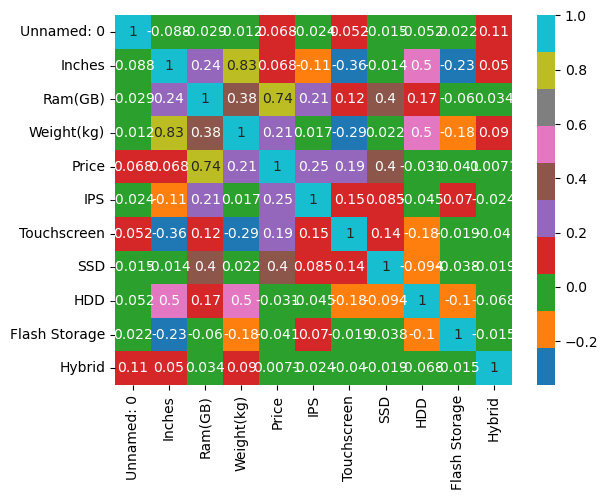

In [46]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='tab10')

In [47]:
x = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression,SGDRegressor,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor, RadiusNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree, ExtraTreeRegressor
#pip install xgboost
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.neural_network import MLPRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        sgd=SGDRegressor()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        rkn=RadiusNeighborsRegressor(radius=1.0)
        ada=AdaBoostRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
        svr=SVR()
        mlp_regressor = MLPRegressor()

       
        
        algos=[L,R,Lass,E,sgd,ETR,GBR,ada,kn,dt,xgb,svr,mlp_regressor]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','SGD','Extra Tree','Gradient Boosting',
                    'KNeighborsRegressor','AdaBoost','Decision Tree','XGBRegressor','SVR','mlp_regressor']
        x=MinMaxScaler().fit_transform(x)
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.20,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [49]:
algo_test(x,y)

,R_Squared,RMSE,MAE
Gradient Boosting,0.801245,16928.723125,10761.238998
XGBRegressor,0.786793,17533.380619,10459.262546
Lasso,0.762164,18518.412905,13200.605760
Linear,0.760978,18564.533691,13246.301520
Ridge,0.753881,18838.107758,13560.017453
SGD,0.694840,20976.274685,15463.800794
Decision Tree,0.650649,22443.753569,14356.720607
KNeighborsRegressor,0.623515,23299.057904,18957.057547
AdaBoost,0.620497,23392.276063,15662.884094
Extra Tree,0.579761,24615.745431,14362.677352


In [51]:
from sklearn.ensemble import RandomForestRegressor


randomfr = RandomForestRegressor()

In [55]:
from sklearn.model_selection import train_test_split

In [56]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [57]:
modelfr = randomfr.fit(x_train, y_train)

In [58]:
tahminfr = modelfr.predict(x_test)

In [59]:
r2_score(y_test, tahminfr)

0.8006601952692088

In [61]:
from sklearn.model_selection import GridSearchCV

# model
rf = RandomForestRegressor(random_state=42)

# parameters to test
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearch
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

# train
grid.fit(x_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.3s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   1.2s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total tim

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [62]:
tahmin = grid.predict(x_test)

In [63]:
r2_score(y_test, tahmin)

0.7932316650149135

In [65]:
grid.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [66]:
grid.best_score_

0.8010380013831615

In [67]:
best_model = grid.best_estimator_

In [68]:
tahminBest_model = best_model.predict(x_test)

In [69]:
r2_score(y_test, tahminBest_model)

0.7932316650149135